In [1]:
%matplotlib widget
from iris_raster import IrisRaster
import glob
import numpy as np
import matplotlib.pyplot as plt
from models import Models
import os
from Functions.utilities import get_extent
from astropy.wcs import WCS
import astropy.units as u
from astropy.coordinates import SkyCoord, SpectralCoord
from sunpy.coordinates import frames
import time
# from ndcube import NDCube
from matplotlib.colors import TwoSlopeNorm
from scipy.optimize import curve_fit
from mpl_toolkits.axes_grid1 import make_axes_locatable
from astropy.constants import c
from Functions.sunpy_map_cut import sunpy_map_cut
from astropy.io import fits
from sunpy.map import Map as sm
from utilities import utilities as utils
from physics import get_dopplershift2wavelength
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d
from scipy import integrate

In [2]:
def plot_spectrum(wavelength,data,err):

    fig = plt.figure(figsize = (15,6))

    ax = fig.add_subplot(1,1,1,)

    # ax.plot(wavelength , data,drawstyle='steps-mid')

    ax.set_xlabel('Wavelength ($\AA$)',fontsize=20,fontweight='medium')
    ax.set_ylabel('Intensity',fontsize=20,fontweight='medium')

    plt.errorbar(
        wavelength,
        data,
        yerr=err,
        drawstyle='steps-mid',
        color='black',
        lolims=0,
        capsize=5,             # Size of error bar caps
        capthick=1,            # Thickness of caps
        ecolor='red',         # Color of error bars
        marker='o',            # Add markers at data points
        markersize=3,
        markerfacecolor='white',
        markeredgecolor='blue',
        label='Data with Errors'
        )
    # plt.tight_layout()
    return fig

In [3]:
def slice_spectralcube_by_spatial_pixel(spectral_cube,row_l,row_u,col_l,col_u):
    """
    row_l is lower row index in spatial coord
    """
    D2 = spectral_cube[col_l:col_u+1,row_l:row_u+1]

    return D2

In [4]:
hdu_index = 3
raster_file = "./../iris_obj/data_aligned/D044/RASTER_FILES/iris_l2_20160319_145728_3623010639_raster_t000_r00000.fits"
aia_171_file = "./../iris_obj/data_aligned/D044/171/2016-03-19T14_59_23.fits"
error_file = f"./../iris_obj/Errors/D044/iris_l2_20160319_145728_3623010639_raster_t000_r00000/ERR_hdu_{hdu_index}.npy"

HDU_Index     Line desc.      Detector

1             C II 1336     FUV1
2             Fe XII 1349     FUV1
3             O I 1356     FUV1
4             Si IV 1394     FUV2
5             Si IV 1403     FUV2
6             2832     NUV
7             2814     NUV
8             Mg II k 2796     NUV

This is O I 1356 line.
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
(16, 776, 338)
(16, 776, 338)
(338,)


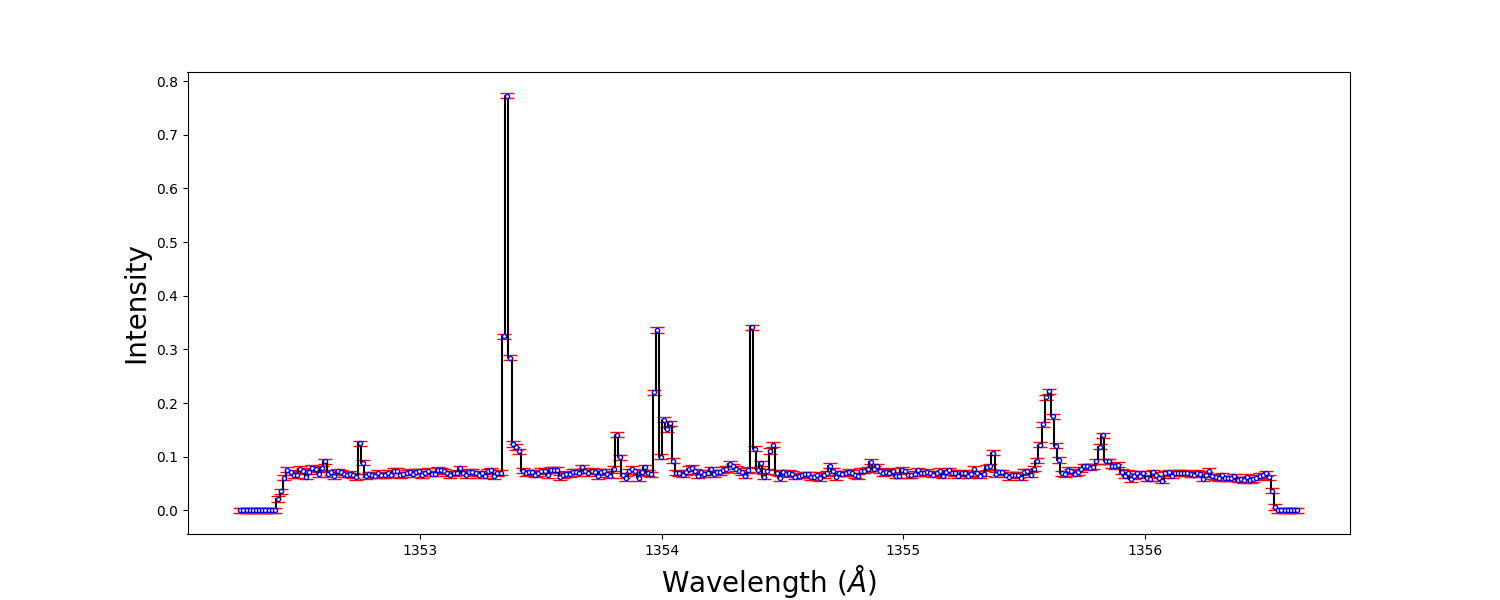

In [5]:
with IrisRaster(raster_file) as raster:

    BG_ext = [10,25,370,390]        # ***** Extension for the background in arcsec.
    y0,y1 = 320,400                 # lower and upper limit of the scans to be shown in the paper
    print(raster)
    
    # m = raster.get_spectroheliogram(hdu_index,np.average(np.array(wrange_k)))  # It is only for finding background corner indices!

    data,hd = raster.get_data_header(hdu_index,print_line=True)

    # ERR = np.load(error_file)|




    data,err,m,wavelength,MS_sub = raster.get_spectral_cube(hdu_index,error_file_dir=f'./Errors/D044',fuv=True)
    
    coordinate_lower = SkyCoord(BG_ext[0]*u.arcsec,BG_ext[2]*u.arcsec,frame=m.coordinate_frame)
    coordinate_upper = SkyCoord(BG_ext[1]*u.arcsec,BG_ext[3]*u.arcsec,frame=m.coordinate_frame)

    col_l,row_l = m.world_to_pixel(coordinate_lower)
    col_u,row_u = m.world_to_pixel(coordinate_upper)
    
    col_l,col_u,row_l,row_u = int(np.rint(col_l.value)),int(np.rint(col_u.value)),int(np.rint(row_l.value)),int(np.rint(row_u.value))

    print(data.shape)
    print(err.shape)
    print(wavelength.shape)

    # data = np.mean(data,axis=(0,1))
    bg_cube = slice_spectralcube_by_spatial_pixel(data,row_l,row_u,col_l,col_u)
    bg_err = slice_spectralcube_by_spatial_pixel(err,row_l,row_u,col_l,col_u)
    # wavelengths = raster.get_wavelengths(hdu_index).value
    # fuv_exp_time = raster.get_nuv_exposure_time()       #********
    # bg_cube = bg_cube/fuv_exp_time[:,np.newaxis,np.newaxis][col_l:col_u+1]  #**********

    mean_bg_spectra = np.mean(bg_cube,axis=(0,1))
    bg_err_sq = bg_err**2
    mean_bg_err = np.sqrt(np.sum(bg_err_sq,axis=(0,1)))/(bg_err.shape[0]*bg_err.shape[1])
    
    fig0 = plot_spectrum(wavelength,mean_bg_spectra,mean_bg_err)
    # print(mean_bg_err.shape)
    # plt.plot(wavelength,data)
    plt.show()

(0.05, 0.19)

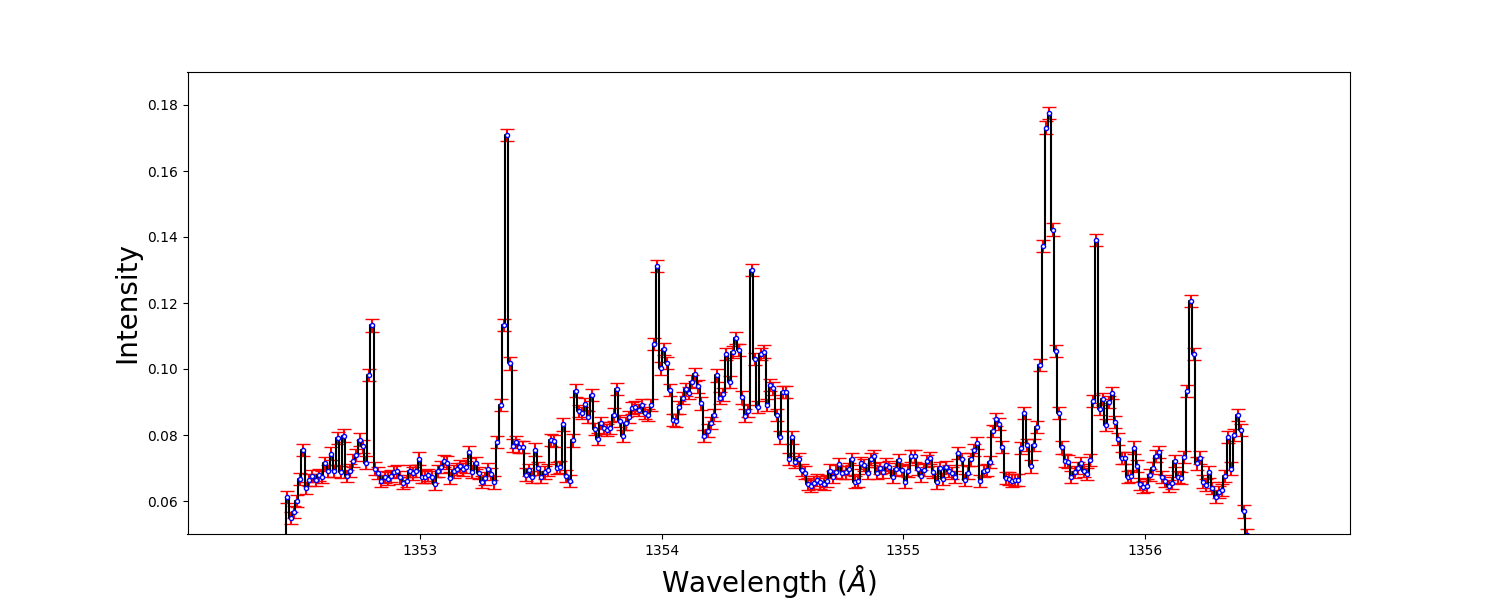

In [6]:
# data = np.mean(data,axis=(0,1))
# data.shape
# err.shape
# wavelength.shape

data = data.mean(axis=(0,1))
err_sq = err**2
err = np.sqrt(np.sum(err_sq,axis=(0,1)))/(err.shape[0]*err.shape[1])
fig1 = plot_spectrum(wavelength,data,err)
fig1.get_axes()[0].set_ylim([0.05,0.190])
# print(fig1.get_axes())


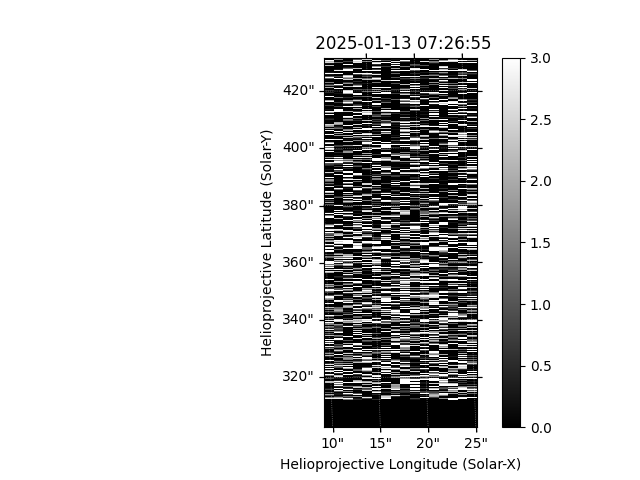

In [12]:
m.peek(aspect=0.05,vmin=0,vmax=3)

In [20]:
L = !Errors/D044/*
L

['/bin/bash: line 1: Errors/D044/iris_l2_20160319_145728_3623010639_raster_t000_r00000: Is a directory']

In [21]:
!Errors/D044/*

/bin/bash: line 1: Errors/D044/iris_l2_20160319_145728_3623010639_raster_t000_r00000: Is a directory
